# MÉTODO DE BISECCIÓN
**Análisis Numérico — Algoritmo 2.1 (Burden, p. 37)**

Este programa implementa el Método de Bisección, un algoritmo numérico iterativo utilizado para aproximar las raíces de una función continua

**Alumna:** *Gomez Aguirre Rocio*  
**Fecha:** *05 de octubre de 2026*

---

## 1. Formulación del problema

Dada una función continua $f$ en $[a, b]$ con $f(a)$ y $f(b)$ de signos opuestos, se busca $p \in (a,b)$ tal que

$$f(p) = 0 .$$

Por el **Teorema del Valor Intermedio**, bajo estas condiciones existe al menos una raíz en $(a,b)$.

## 2. El método

En cada iteración se calcula el punto medio $p = a + \frac{b-a}{2}$ y se conserva la mitad del intervalo donde $f$ cambia de signo. Se detiene cuando $f(p)=0$ o cuando $\frac{b-a}{2} < TOL$.


## 3. Implementación en Python

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def biseccion(f, a, b, TOL, N0):
    # Algoritmo 2.1 (Burden). Regresa la aproximación p y el historial de iteraciones.

    # Hipótesis del método: f(a) y f(b) con signos opuestos
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) y f(b) deben tener signos opuestos.")

    historial = []        # aquí se guarda cada iteración para la tabla
    i = 1                 # Paso 1
    FA = f(a)             # Paso 1

    while i <= N0:                         # Paso 2
        p = a + (b - a) / 2                # Paso 3: punto medio
        FP = f(p)                          # Paso 3
        error = (b - a) / 2                # cota del error en esta iteración
        historial.append((i, a, FA, b, f(b), p, FP, error))

        if FP == 0 or error < TOL:         # Paso 4: criterio de paro
            return p, historial

        i = i + 1                          # Paso 5

        if FA * FP > 0:                    # Paso 6
            a = p                          # la raíz está en [p, b]
            FA = FP
        else:
            b = p                          # la raíz está en [a, p]

    # Paso 7: se acabaron las iteraciones sin lograr la tolerancia
    print(f"El método fracasó después de {N0} iteraciones, N0 = {N0}")
    return None, historial

## 4. Prueba: Ejemplo 1 (Burden, p. 38)

Se busca la raíz de $f(x) = x^3 + 4x^2 - 10$ en $[1, 2]$. Como $f(1) = -5 < 0$ y $f(2) = 14 > 0$, hay cambio de signo.

In [11]:
def funcion1(x):
    return x**3 + 4*(x**2) - 10

# Datos de entrada
a = 1
b = 2
tol = 10**-4      # tolerancia
nmax = 100        # número máximo de iteraciones

print("f(a) =", funcion1(a), "  f(b) =", funcion1(b))

f(a) = -5   f(b) = 14


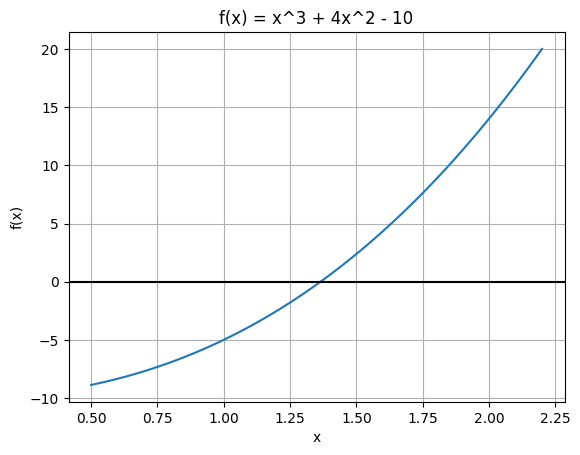

In [12]:
# Gráfica de la función
x = np.linspace(0.5, 2.2, 100)
y = funcion1(x)

plt.plot(x, y)
plt.axhline(0, color="black")   # eje x
plt.title("f(x) = x^3 + 4x^2 - 10")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

### Iteraciones

In [13]:
p, historial = biseccion(funcion1, a, b, tol, nmax)

print(f"{'iter':>4} {'a':>12} {'f(a)':>12} {'b':>12} {'f(b)':>12} {'p':>12} {'f(p)':>12} {'error':>12}")
print("-" * 98)
for fila in historial:
    print("{:>4d} {:12.6f} {:12.6f} {:12.6f} {:12.6f} {:12.6f} {:12.6f} {:12.6f}".format(*fila))

iter            a         f(a)            b         f(b)            p         f(p)        error
--------------------------------------------------------------------------------------------------
   1     1.000000    -5.000000     2.000000    14.000000     1.500000     2.375000     0.500000
   2     1.000000    -5.000000     1.500000     2.375000     1.250000    -1.796875     0.250000
   3     1.250000    -1.796875     1.500000     2.375000     1.375000     0.162109     0.125000
   4     1.250000    -1.796875     1.375000     0.162109     1.312500    -0.848389     0.062500
   5     1.312500    -0.848389     1.375000     0.162109     1.343750    -0.350983     0.031250
   6     1.343750    -0.350983     1.375000     0.162109     1.359375    -0.096409     0.015625
   7     1.359375    -0.096409     1.375000     0.162109     1.367188     0.032356     0.007812
   8     1.359375    -0.096409     1.367188     0.032356     1.363281    -0.032150     0.003906
   9     1.363281    -0.032150     1.

## 5. Solución final

In [14]:
if p is not None:
    print("=" * 55)
    print(f"  SOLUCIÓN FINAL: p = {p:.9f}")
    print(f"  f(p) = {funcion1(p):.3e}")
    print(f"  Raíz en el intervalo [{a}, {b}], con {len(historial)} iteraciones")
    print("=" * 55)

  SOLUCIÓN FINAL: p = 1.365173340
  f(p) = -9.358e-04
  Raíz en el intervalo [1, 2], con 14 iteraciones


### Gráfica de la raíz

El punto rojo es la solución final $p$, donde la curva cruza el eje $x$.

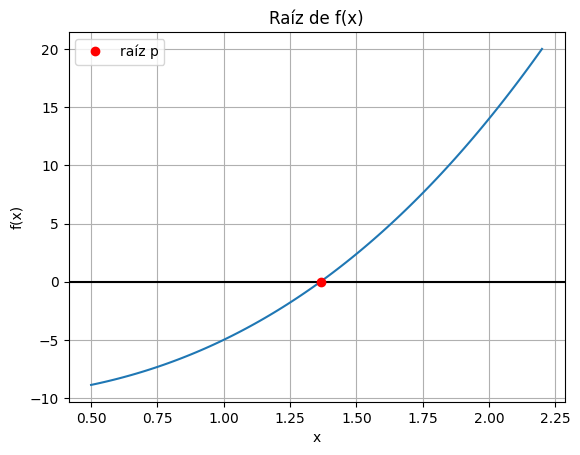

In [15]:
plt.plot(x, y)
plt.axhline(0, color="black")
plt.plot(p, 0, "ro", label="raíz p")   # punto rojo en la solución
plt.title("Raíz de f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

### Error en cada iteración

El error $(b-a)/2$ se reduce a la mitad en cada iteración.

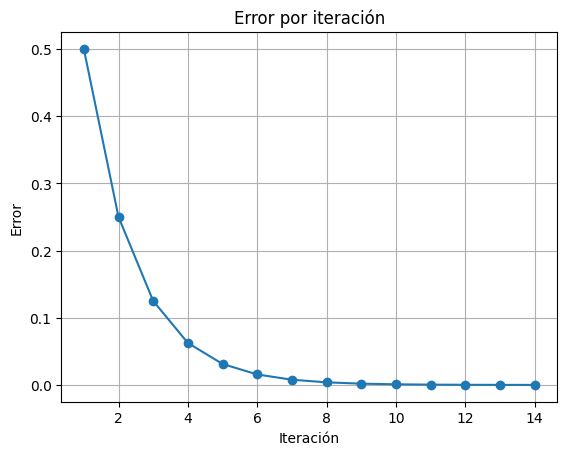

In [16]:
iteraciones = [fila[0] for fila in historial]
errores = [fila[7] for fila in historial]

plt.plot(iteraciones, errores, "o-")
plt.title("Error por iteración")
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.grid()
plt.show()

## 6. Conclusiones

- El método converge siempre que $f$ sea continua y haya cambio de signo en $[a,b]$.
- El error se reduce a la mitad en cada iteración: la convergencia es lenta pero segura.
